# Objective 1: Data Cleaning

In [3]:
import pandas as pd

df = pd.read_csv("BigBasket Products.csv")

print(df.head())

print("\nMissing values:\n", df.isnull().sum())

df = df.drop_duplicates()

df['Brand'] = df['brand'].fillna("Unknown")

df = df.dropna(subset=['market_price', 'sale_price'])

print("\nCleaned data shape:", df.shape)

   index                                            product  \
0    1.0             Garlic Oil - Vegetarian Capsule 500 mg   
1    2.0                              Water Bottle - Orange   
2    3.0                     Brass Angle Deep - Plain, No.2   
3    4.0  Cereal Flip Lid Container/Storage Jar - Assort...   
4    5.0                 Creme Soft Soap - For Hands & Body   

                 category           sub_category              brand  \
0        Beauty & Hygiene              Hair Care  Sri Sri Ayurveda    
1  Kitchen, Garden & Pets  Storage & Accessories         Mastercook   
2    Cleaning & Household            Pooja Needs                Trm   
3    Cleaning & Household   Bins & Bathroom Ware             Nakoda   
4        Beauty & Hygiene       Bath & Hand Wash              Nivea   

   sale_price  market_price                      type  rating  \
0       220.0         220.0          Hair Oil & Serum     4.1   
1       180.0         180.0    Water & Fridge Bottles     2.3   

# Objective 2: Data Type Info and Summary

In [4]:
print("\nData Types:\n", df.dtypes)

print("\nSummary Statistics:\n", df.describe(include='all'))


Data Types:
 index           float64
product          object
category         object
sub_category     object
brand            object
sale_price      float64
market_price    float64
type             object
rating          float64
description      object
Brand            object
dtype: object

Summary Statistics:
                index                       product          category  \
count   20549.000000                         20548             20549   
unique           NaN                         18116                11   
top              NaN  Turmeric Powder/Arisina Pudi  Beauty & Hygiene   
freq             NaN                            17              5845   
mean    10275.000000                           NaN               NaN   
std      5932.129677                           NaN               NaN   
min         1.000000                           NaN               NaN   
25%      5138.000000                           NaN               NaN   
50%     10275.000000                  

# Objective 3: Count of Unique Products and Categories

In [5]:
print("Total unique products:", df['product'].nunique())

print("Total unique categories:", df['category'].nunique())

Total unique products: 18116
Total unique categories: 11


# Objective 4: Visualize Missing Values as a Bar Chart

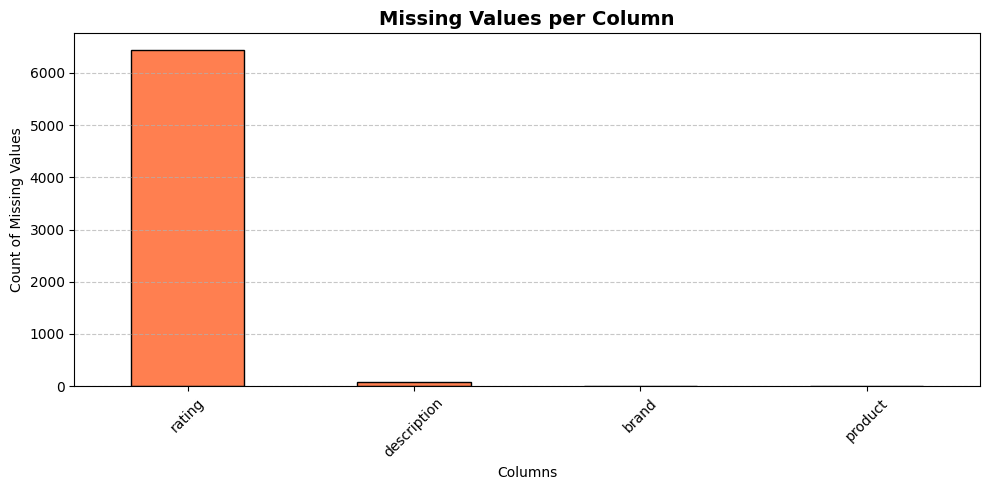

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
missing_values.plot(kind='bar', color='coral', edgecolor='black')

plt.title("Missing Values per Column", fontsize=14, fontweight='bold')
plt.xlabel("Columns")
plt.ylabel("Count of Missing Values")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Objective 5: Top 10 Expensive Products

In [7]:
top_expensive = df.sort_values(by='market_price', ascending=False).head(10)
print("\nTop 10 Expensive Products:\n", top_expensive[['product', 'market_price']])



Top 10 Expensive Products:
                                                  product  market_price
12669                   Epilator SE9-9961 Legs-Body-Face       10769.0
1056   Gas Stove-3 Burner Royale Plus Schott Glass, B...       10695.0
6893   Gas Stove-2 Burner Royale Plus Schott Glass, B...        7875.0
1766                   Good Girl Eau De Parfum For Women        7400.0
2781                              Extra Virgin Olive Oil        7299.0
6034                                 Whey Protein Powder        6700.0
13962                Black Edition Eau De Parfum For Men        6600.0
10940             Bentley Absolute Eau De Parfum For Men        6600.0
17605  3 Burner Gas Stove - Magic Glass Tables, GTMC ...        6595.0
5464                            Olive Oil - Extra Virgin        6500.0


# Objective 6: Most Common Brands

In [8]:
top_brands = df['Brand'].value_counts().head(10)
print("\nTop 10 Brands:\n", top_brands)



Top 10 Brands:
 Brand
Fresho              483
bb Royal            380
BB Home             323
DP                  179
Fresho Signature    135
bb Combo            122
Amul                111
INATUR              110
GoodDiet            105
Dabur                99
Name: count, dtype: int64


# Objective 7: Price Distribution (Histogram)

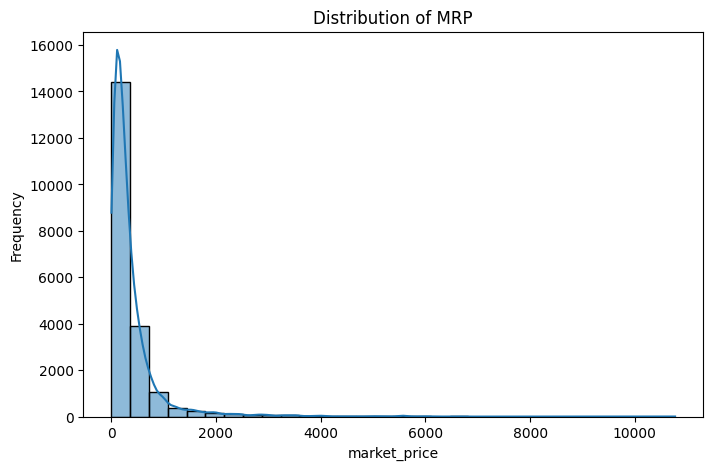

In [9]:
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.histplot(df['market_price'], bins=30, kde=True)
plt.title("Distribution of MRP")
plt.xlabel("market_price")
plt.ylabel("Frequency")
plt.show()


# Objective 8: Relationship Between MRP and Selling Price

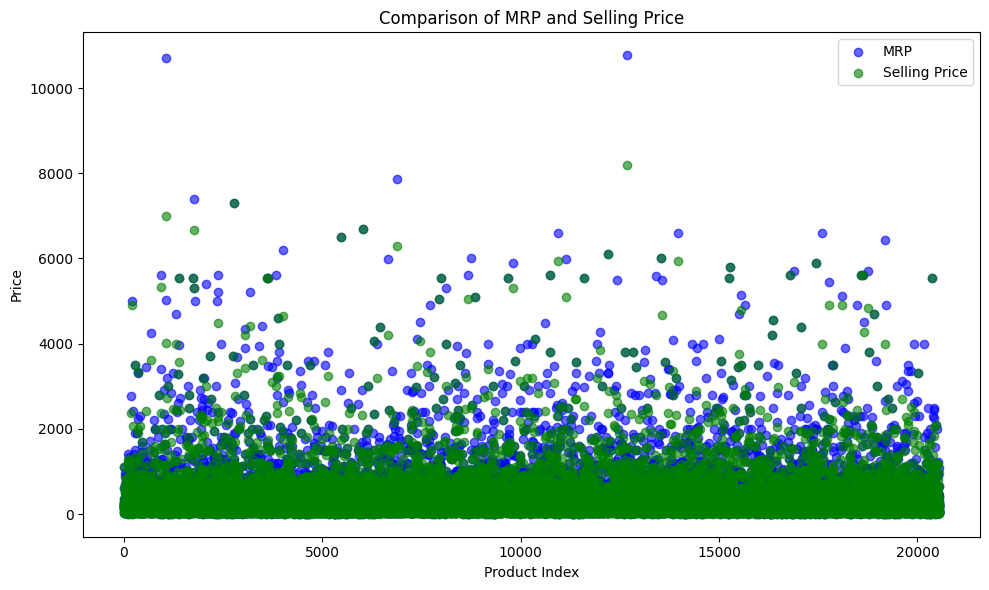

In [10]:
import matplotlib.pyplot as plt

df = df.reset_index()

plt.figure(figsize=(10, 6))

plt.scatter(df['index'], df['market_price'], color='blue', label='MRP', alpha=0.6)

plt.scatter(df['index'], df['sale_price'], color='green', label='Selling Price', alpha=0.6)

plt.title("Comparison of MRP and Selling Price")
plt.xlabel("Product Index")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()


# Objective 9: Discount Percentage Column

In [11]:
df['Discount (%)'] = ((df['market_price'] - df['sale_price']) / df['market_price']) * 100
print("\nDiscount column added.\n", df[['product', 'market_price', 'sale_price', 'Discount (%)']].head())



Discount column added.
                                              product  market_price  \
0             Garlic Oil - Vegetarian Capsule 500 mg         220.0   
1                              Water Bottle - Orange         180.0   
2                     Brass Angle Deep - Plain, No.2         250.0   
3  Cereal Flip Lid Container/Storage Jar - Assort...         176.0   
4                 Creme Soft Soap - For Hands & Body         162.0   

   sale_price  Discount (%)  
0       220.0      0.000000  
1       180.0      0.000000  
2       119.0     52.400000  
3       149.0     15.340909  
4       162.0      0.000000  


# Objective 10: Summary Statistics of MRP

In [12]:
print("Mean MRP:", df['market_price'].mean())
print("Median MRP:", df['market_price'].median())
print("Standard Deviation of MRP:", df['market_price'].std())


Mean MRP: 378.8608049053482
Median MRP: 220.0
Standard Deviation of MRP: 565.8094159945592


# Objective 11: Category-wise Product Count

In [13]:
category_count = df['category'].value_counts()
print("\nProduct Count per Category:\n", category_count)



Product Count per Category:
 category
Beauty & Hygiene            5845
Gourmet & World Food        3525
Kitchen, Garden & Pets      2669
Snacks & Branded Foods      2092
Cleaning & Household        2004
Foodgrains, Oil & Masala    1978
Bakery, Cakes & Dairy        650
Beverages                    649
Baby Care                    457
Fruits & Vegetables          420
Eggs, Meat & Fish            260
Name: count, dtype: int64


# Objective 12: Boxplot of Selling Price by Category

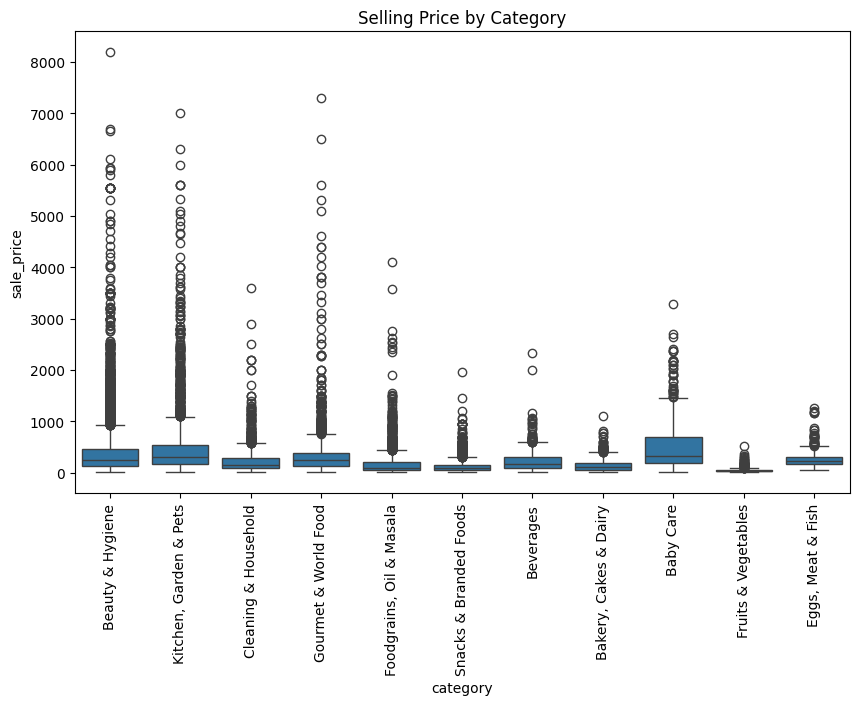

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='category', y='sale_price', data=df)
plt.xticks(rotation=90)
plt.title("Selling Price by Category")
plt.show()


# Objective 13: Correlation Analysis


Correlation Matrix:
               market_price  sale_price  Discount (%)
market_price      1.000000    0.963390      0.176014
sale_price        0.963390    1.000000      0.018491
Discount (%)      0.176014    0.018491      1.000000


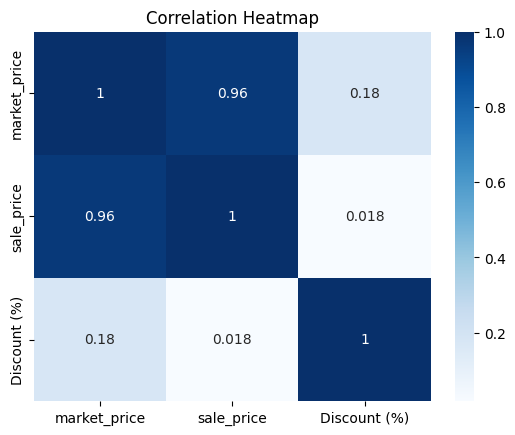

In [15]:
# Correlation matrix
corr = df[['market_price', 'sale_price', 'Discount (%)']].corr()
print("\nCorrelation Matrix:\n", corr)

# Heatmap
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()


# Objective 14: Top Selling Products (Lowest Price)

In [16]:
cheapest = df.sort_values(by='sale_price').head(10)
print("\nTop 10 Cheapest Products:\n", cheapest[['product', 'sale_price']])



Top 10 Cheapest Products:
                                            product  sale_price
15926                      Dreams Cup Cake - Choco         5.0
16551                 Biscuits - Magix Kreams Choc         5.0
2761   Orbit Sugar-Free Chewing Gum - Lemon & Lime         5.0
9971             Tomato - Local, Organically Grown         5.0
17943                        Fulltoss Tangy Tomato         5.0
11435                          Exam Standard Scale         5.0
14184            Tomato - Local, Organically Grown         5.0
17640                  Hand Wash - Moisture Shield         5.0
2978          Sugar Free Chewing Gum - Mixed Fruit         5.0
14603                      50-50 Timepass Biscuits         5.0


# Objective 15: Outlier Detection (IQR Method)

In [17]:
# IQR calculation
Q1 = df['market_price'].quantile(0.25)
Q3 = df['market_price'].quantile(0.75)
IQR = Q3 - Q1

# Detect outliers
outliers = df[(df['market_price'] < Q1 - 1.5 * IQR) | (df['market_price'] > Q3 + 1.5 * IQR)]
print("\nNumber of outliers in MRP:", outliers.shape[0])



Number of outliers in MRP: 1570
